In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, BatchNormalization
from keras.utils import to_categorical, np_utils

Using TensorFlow backend.


### Read h5 file and explore the dataset

In [0]:
f = h5py.File('/content/drive/My Drive/aiml/datasets/SVHN/SVHN_single_grey1.h5','r') 

In [6]:
list(f)

['X_test', 'X_train', 'X_val', 'y_test', 'y_train', 'y_val']

In [0]:
X_train = np.array(f['X_train'])
X_test = np.array(f['X_test'])
y_train = np.array(f['y_train'])
y_test = np.array(f['y_test'])

In [8]:
print('X_train shape =',X_train.shape)
print('X_test shape =',X_test.shape)
print('y_train shape =',y_train.shape)
print('y_test shape =',y_test.shape)

X_train shape = (42000, 32, 32)
X_test shape = (18000, 32, 32)
y_train shape = (42000,)
y_test shape = (18000,)


In [0]:
# Normalize the dataset to have values from 0 to 1
X_train = X_train / 255.0
X_test = X_test / 255.0

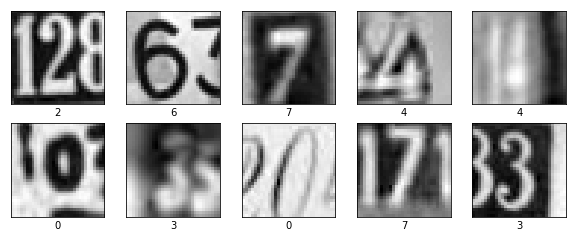

In [10]:
#Plot first 10 images in the triaining set and their labels.
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i],cmap='gray')
    plt.xlabel(y_train[i])
plt.show()

###Implement kNN Classifier

In [11]:
# Reshape dataset
knnX_train = X_train.reshape(42000,1024)
knnX_test = X_test.reshape(18000,1024)
print(X_train.shape)
print(knnX_train.shape)

(42000, 32, 32)
(42000, 1024)


In [12]:
k_range = [1,3,5,9]
resultsDf = pd.DataFrame({'Number of Neighbors':[],'Accuracy':[]})
for k in k_range:
  #Create KNN Classifier
  knnmodel = KNeighborsClassifier(n_neighbors=k)
  #Train the model using the training sets
  knnmodel.fit(knnX_train, y_train)
  #Predict the response for test dataset
  knny_pred = knnmodel.predict(knnX_test)
  Accuracy = accuracy_score(y_test, knny_pred)
  resultsDf = resultsDf.append({'Number of Neighbors': k,'Accuracy':Accuracy}, ignore_index=True)
resultsDf

,Number of Neighbors,Accuracy
0,1.0,0.459167
1,3.0,0.461778
2,5.0,0.490167
3,9.0,0.512444


In [15]:
#Sample predictions
for i in range(10):
  print("Actual value=",y_test[i],"Predicted value=",knny_pred[i])

Actual value= 1 Predicted value= 9
Actual value= 7 Predicted value= 7
Actual value= 2 Predicted value= 2
Actual value= 9 Predicted value= 9
Actual value= 0 Predicted value= 0
Actual value= 9 Predicted value= 9
Actual value= 1 Predicted value= 1
Actual value= 8 Predicted value= 6
Actual value= 4 Predicted value= 8
Actual value= 4 Predicted value= 4


In [33]:
#Classification Metric Report
clr=metrics.classification_report(f['y_test'],knny_pred)
print(clr)

              precision    recall  f1-score   support

           0       0.43      0.68      0.52      1814
           1       0.46      0.73      0.56      1828
           2       0.57      0.55      0.56      1803
           3       0.42      0.41      0.42      1719
           4       0.64      0.63      0.64      1812
           5       0.49      0.38      0.43      1768
           6       0.49      0.40      0.44      1832
           7       0.73      0.60      0.66      1808
           8       0.45      0.34      0.39      1812
           9       0.56      0.39      0.46      1804

    accuracy                           0.51     18000
   macro avg       0.52      0.51      0.51     18000
weighted avg       0.52      0.51      0.51     18000



### Implement and apply Neural Network Classifier

In [16]:
#Encoding the output class label (One-Hot Encoding)
y_train=np_utils.to_categorical(y_train,10)
y_test=np_utils.to_categorical(y_test,10)
y_train[0:2]

array([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]], dtype=float32)

In [17]:
dimData = np.prod(X_train.shape[1:])
print("dimData=",dimData)

dimData= 1024


In [18]:
# create NN model
model = Sequential()
model.add(Flatten(input_shape=(32, 32)))
model.add(Dense(128, activation='relu', input_shape=(dimData,)))
model.add(Dense(128,activation='relu'))
model.add(Dense(10, activation='softmax')) # 10 outputs

W0902 17:43:50.899968 140171308312448 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:66: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

W0902 17:43:50.958018 140171308312448 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:541: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0902 17:43:50.989726 140171308312448 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:4432: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.



In [19]:
# Compile model
model.compile(loss='categorical_crossentropy', optimizer='sgd', metrics=['accuracy'])

W0902 17:43:57.873201 140171308312448 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/optimizers.py:793: The name tf.train.Optimizer is deprecated. Please use tf.compat.v1.train.Optimizer instead.

W0902 17:43:57.902870 140171308312448 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:3576: The name tf.log is deprecated. Please use tf.math.log instead.



In [20]:
# Fit the model
model.fit(X_train, y_train, validation_data=(X_test,y_test), epochs=10, batch_size=5)

W0902 17:44:04.088901 140171308312448 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/math_grad.py:1250: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where
W0902 17:44:04.142514 140171308312448 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:1033: The name tf.assign_add is deprecated. Please use tf.compat.v1.assign_add instead.



Train on 42000 samples, validate on 18000 samples
Epoch 1/10
42000/42000 [==============================] - 34s 815us/step - loss: 1.9031 - acc: 0.3260 - val_loss: 1.3460 - val_acc: 0.5601
Epoch 2/10
42000/42000 [==============================] - 33s 786us/step - loss: 1.2716 - acc: 0.5883 - val_loss: 1.1074 - val_acc: 0.6530
Epoch 3/10
42000/42000 [==============================] - 31s 727us/step - loss: 1.0966 - acc: 0.6548 - val_loss: 0.9792 - val_acc: 0.6964
Epoch 4/10
42000/42000 [==============================] - 30s 711us/step - loss: 0.9960 - acc: 0.6883 - val_loss: 0.9579 - val_acc: 0.7061
Epoch 5/10
42000/42000 [==============================] - 30s 715us/step - loss: 0.9279 - acc: 0.7120 - val_loss: 0.8986 - val_acc: 0.7209
Epoch 6/10
42000/42000 [==============================] - 26s 617us/step - loss: 0.8755 - acc: 0.7291 - val_loss: 0.8885 - val_acc: 0.7230
Epoch 7/10
42000/42000 [==============================] - 30s 717us/step - loss: 0.8338 - acc: 0.7433 - val_loss: 0.

In [21]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_1 (Flatten)          (None, 1024)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 128)               131200    
_________________________________________________________________
dense_2 (Dense)              (None, 128)               16512     
_________________________________________________________________
dense_3 (Dense)              (None, 10)                1290      
Total params: 149,002
Trainable params: 149,002
Non-trainable params: 0
_________________________________________________________________


In [22]:
#Model Evaluation
score = model.evaluate(X_test, y_test, verbose=0)
score

[0.7895840800603231, 0.7617777777777778]

In [0]:
#In the above NN model let us try implementing Batch Normalization, Dropout
model1 = Sequential()
model1.add(BatchNormalization(input_shape=(32, 32)))
model1.add(Flatten(input_shape=(32, 32)))
model1.add(Dense(128, activation='relu', input_shape=(dimData,)))
model1.add(Dropout(0.5))
model1.add(Dense(128,activation='relu'))
model1.add(Dense(10, activation='softmax')) # 10 outputs

In [0]:
from keras.optimizers import SGD
#opt = SGD(lr=0.005)
sgd = SGD(lr=0.005, decay=1e-6, momentum=0.9, nesterov=True)
# Compile model
model1.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

In [26]:
# Fit the model
history = model1.fit(X_train, y_train, validation_data=(X_test,y_test), epochs=50, batch_size=32)

Train on 42000 samples, validate on 18000 samples
Epoch 1/50
42000/42000 [==============================] - 8s 196us/step - loss: 1.6241 - acc: 0.4490 - val_loss: 1.0505 - val_acc: 0.6885
Epoch 2/50
42000/42000 [==============================] - 8s 192us/step - loss: 1.1951 - acc: 0.6259 - val_loss: 0.9036 - val_acc: 0.7347
Epoch 3/50
42000/42000 [==============================] - 8s 195us/step - loss: 1.0952 - acc: 0.6599 - val_loss: 0.8462 - val_acc: 0.7532
Epoch 4/50
42000/42000 [==============================] - 8s 198us/step - loss: 1.0269 - acc: 0.6855 - val_loss: 0.7942 - val_acc: 0.7673
Epoch 5/50
42000/42000 [==============================] - 8s 195us/step - loss: 0.9752 - acc: 0.7013 - val_loss: 0.7593 - val_acc: 0.7822
Epoch 6/50
42000/42000 [==============================] - 8s 194us/step - loss: 0.9439 - acc: 0.7096 - val_loss: 0.7438 - val_acc: 0.7837
Epoch 7/50
42000/42000 [==============================] - 8s 193us/step - loss: 0.9223 - acc: 0.7179 - val_loss: 0.7237 - 

In [27]:
#Model Evaluation
score1 = model1.evaluate(X_test, y_test, verbose=0)
score1

[0.5508654492166307, 0.837]

Text(0.5, 1.0, 'Loss Curves')

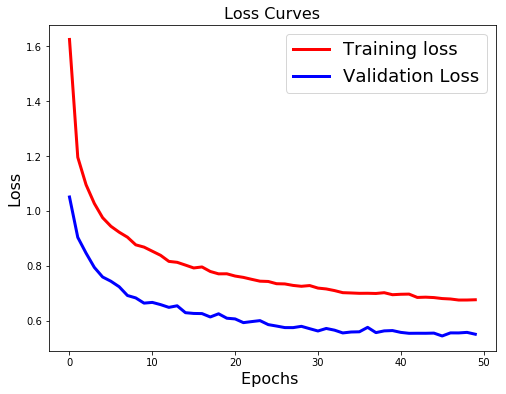

In [28]:
plt.figure(figsize=[8,6])
plt.plot(history.history['loss'],'r',linewidth=3.0)
plt.plot(history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)

Text(0.5, 1.0, 'Accuracy Curves')

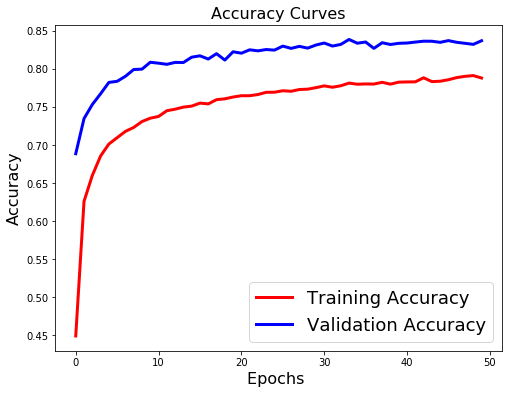

In [29]:
plt.figure(figsize=[8,6])
plt.plot(history.history['acc'],'r',linewidth=3.0)
plt.plot(history.history['val_acc'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)

In [0]:
# Confusion Matrix
from sklearn import metrics
y_predict = model.predict(X_test)

In [31]:
y_pred = []
for val in y_predict:
    y_pred.append(np.argmax(val))
cm = metrics.confusion_matrix(f['y_test'],y_pred)
print(cm)

[[1461   46   25   38   63   13   71   29   26   42]
 [  25 1498   23   48   57   14   23  104   17   19]
 [  20   41 1441   67   26   20   17  123   13   35]
 [  25   50   53 1260   24  135   15   69   40   48]
 [  62  100   26   30 1452   28   47   18   26   23]
 [  33   35   21  140   16 1305   72   22   77   47]
 [  86   46   17   25   76   58 1340   18  145   21]
 [  25   68   79   48   20   15   13 1500   19   21]
 [  53   68   31   78   47   59  145   19 1231   81]
 [ 144   50   39   67   41  116   23   60   40 1224]]


In [35]:
#Classification Metric Report
cr=metrics.classification_report(f['y_test'],y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.76      0.81      0.78      1814
           1       0.75      0.82      0.78      1828
           2       0.82      0.80      0.81      1803
           3       0.70      0.73      0.72      1719
           4       0.80      0.80      0.80      1812
           5       0.74      0.74      0.74      1768
           6       0.76      0.73      0.74      1832
           7       0.76      0.83      0.80      1808
           8       0.75      0.68      0.71      1812
           9       0.78      0.68      0.73      1804

    accuracy                           0.76     18000
   macro avg       0.76      0.76      0.76     18000
weighted avg       0.76      0.76      0.76     18000



**Differences and trade-offs between KNN model and Deep Neural Network model for this SVHN Dataset.**


*   Neural Network model has outperformed for this SVHN dataset. Best Accuracy achieved is 83% compared to 51% achieved for KNN model.
*   Training the Neural Network took comparitively higher time. In KNN model, the training phase is faster.
*   Testing/prediction in Neural Network was pretty fast.Whereas in KNN model it took close to 2 hours for predictions on 18K test dataset. Thus, making KNN computationally more expensive in terms of time and memory for larger datasets.
*   There is only one parameter to deal with i.e., value of nearest neighbors (k) in KNN model.
Whereas, for Neural Network there are many hyperparameters  like loss function, optimizer etc. and other Hidden layers like BatchNormalization, Droput that help in improving performance metrics. 




